# 🌊 Tema 9: Visualización de Datos con Python (Parte II) - Seaborn

¡Bienvenido/a al último tema del Módulo 1!

En el tema anterior aprendimos a construir gráficos desde cero con Matplotlib. Ahora daremos el salto a **Seaborn**, una librería construida *sobre* Matplotlib, pero diseñada específicamente para hacer que la visualización estadística sea atractiva, moderna y con muchísimo menos código.

## 🚀 Contenido del Cuaderno

1. **Introducción y Estilos:** Conoce Seaborn y personaliza tus gráficos al instante.
2. **Gráficos Estadísticos:** Funciones de Densidad Kernel (KDE) y Violinplots.
3. **Análisis de Relaciones:** Regplot, lmplot y mapas de calor (Heatmaps).
4. **Gráficos Compuestos:** Jointplots y Facet Grids.
5. **Ejercicio Práctico:** Análisis bivariado del dataset "Tips" (Propinas).
6. **Nivel Pro:** Matrices de Correlación y Gráficos Multivariados complejos.
7. **Glosario Técnico y Conclusión del Módulo.**

---
> **Instrucciones:** Ejecuta las celdas de código paso a paso. Asegúrate de tener instalada la librería usando `pip install seaborn`.

## 1. Conoce Seaborn y Personaliza tus Gráficos

Una de las mayores ventajas de Seaborn son sus **Styles** (Estilos) integrados. Con una sola instrucción matemática, transforma un gráfico aburrido en una visualización de nivel corporativo.

Los temas principales son: `darkgrid` (cuadrícula oscura), `whitegrid` (cuadrícula blanca), `dark`, `white`, y `ticks`.

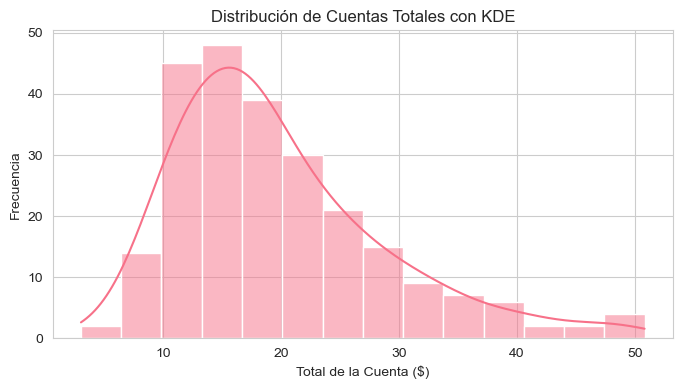

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargamos un dataset de prueba integrado en Seaborn (Propinas de un restaurante)
df_tips = sns.load_dataset('tips')

# 1. Personalización: Aplicamos un tema general para todos los gráficos
sns.set_style("whitegrid")
sns.set_palette("husl") # Paleta de colores moderna

# 2. Gráfico básico con KDE (Función de Densidad Kernel)
plt.figure(figsize=(8, 4))
sns.histplot(data=df_tips, x="total_bill", kde=True)

plt.title("Distribución de Cuentas Totales con KDE")
plt.xlabel("Total de la Cuenta ($)")
plt.ylabel("Frecuencia")
plt.show()

## 2. Tipos Adicionales y Gráficos Compuestos


* **Violinplot:** Es una evolución del Diagrama de Caja. No solo muestra la mediana y los cuartiles, sino que dibuja la "silueta" de la densidad de los datos (KDE) a los lados.
* **Jointplot:** Es un gráfico compuesto. Combina un diagrama de dispersión en el centro para ver la relación entre dos variables, y gráficos de distribución (histogramas o densidades) en los márgenes superior y derecho.

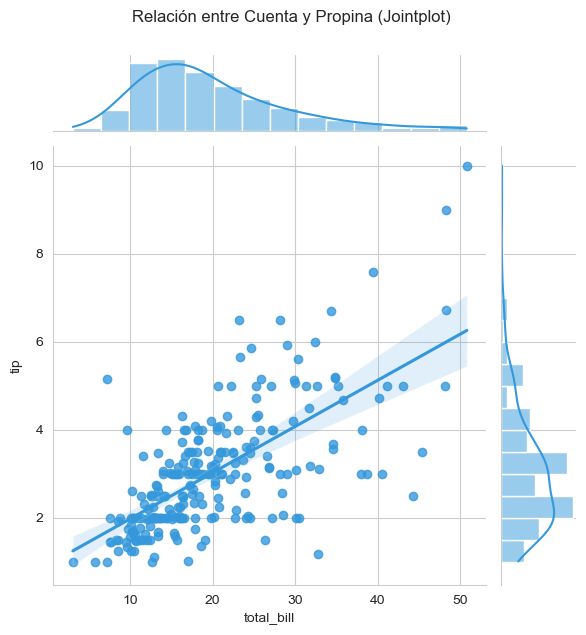

In [2]:
# 💡 Ejemplo: Gráfico Compuesto (Jointplot)
# Muestra la relación entre la cuenta total y la propina dejada
grafico_compuesto = sns.jointplot(data=df_tips, x="total_bill", y="tip", kind="reg", color="#3498db")

# Ajustamos el título (los jointplots requieren un ajuste especial para el título)
grafico_compuesto.figure.suptitle("Relación entre Cuenta y Propina (Jointplot)", y=1.05)
plt.show()

---
## 📝 Ejercicio Práctico: Análisis Exploratorio Rápido

Como preparación para el proyecto final, realizaremos un análisis visual de cómo se comportan las propinas en el restaurante dependiendo del día de la semana.

**Objetivo:**
1. Crear un **Violinplot** que muestre la distribución de las cuentas totales (`total_bill`) divididas por día de la semana (`day`).
2. Crear un gráfico de regresión (`lmplot`) que evalúe si el tamaño de la cuenta afecta la propina (`tip`), separando las tendencias entre fumadores y no fumadores.

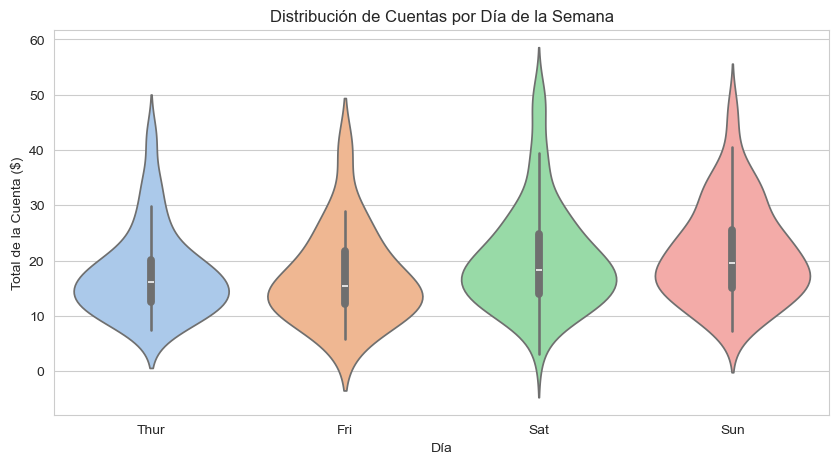

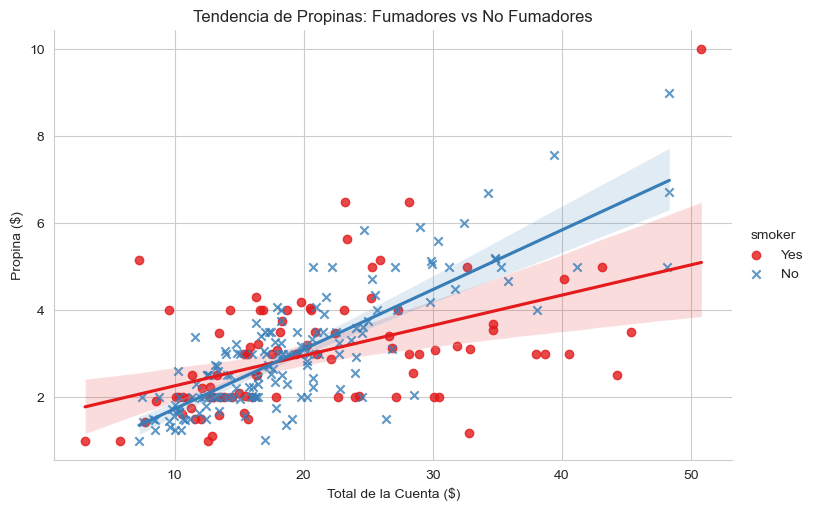

In [5]:
# --- Solución Ejercicio Normal ---

# 1. Creación del Violinplot (Actualizado para Seaborn v0.14.0+)
plt.figure(figsize=(10, 5))

# Asignamos hue="day" y legend=False para evitar el FutureWarning
sns.violinplot(data=df_tips, x="day", y="total_bill", hue="day", palette="pastel", legend=False)

plt.title("Distribución de Cuentas por Día de la Semana")
plt.xlabel("Día")
plt.ylabel("Total de la Cuenta ($)")
plt.show()

# 2. Creación del lmplot (Scatter plot + Línea de Regresión segmentada)
# El parámetro 'hue' nos permite separar automáticamente por categorías (fumador/no fumador)
sns.lmplot(data=df_tips, x="total_bill", y="tip", hue="smoker", markers=["o", "x"], palette="Set1", height=5, aspect=1.5)
plt.title("Tendencia de Propinas: Fumadores vs No Fumadores")
plt.xlabel("Total de la Cuenta ($)")
plt.ylabel("Propina ($)")
plt.show()

## 🔍 Explicación de los Algoritmos

1. **El poder de `hue`:** En Seaborn, el parámetro `hue` (matiz) es mágico. En el `lmplot`, con solo decirle `hue="smoker"`, Seaborn dividió los datos, pintó los puntos de distintos colores, dibujó dos líneas de regresión independientes y generó una leyenda, ¡todo automáticamente! En Matplotlib puro, esto tomaría unas 15 líneas de código.
2. **Lectura del Violinplot:** Observa cómo el violín del sábado ("Sat") es más "gordo" en la parte baja y muy estirado hacia arriba. Esto indica que la mayoría de las cuentas son moderadas, pero hay unos pocos clientes que gastan muchísimo ese día.

## 🚀 Nivel Pro: Mapas de Calor y Facet Grid

En un entorno profesional, uno de los primeros pasos de cualquier modelo de Machine Learning es encontrar qué variables numéricas están altamente correlacionadas. Para esto usamos el **Mapa de Calor (Heatmap)**.

Además, cuando queremos comparar múltiples variables categóricas simultáneamente sin hacer un gráfico confuso, utilizamos **Facet Grid** para crear una matriz de pequeños gráficos limpios.

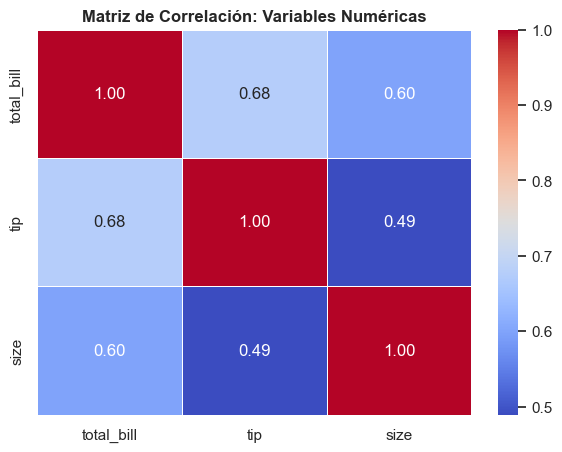

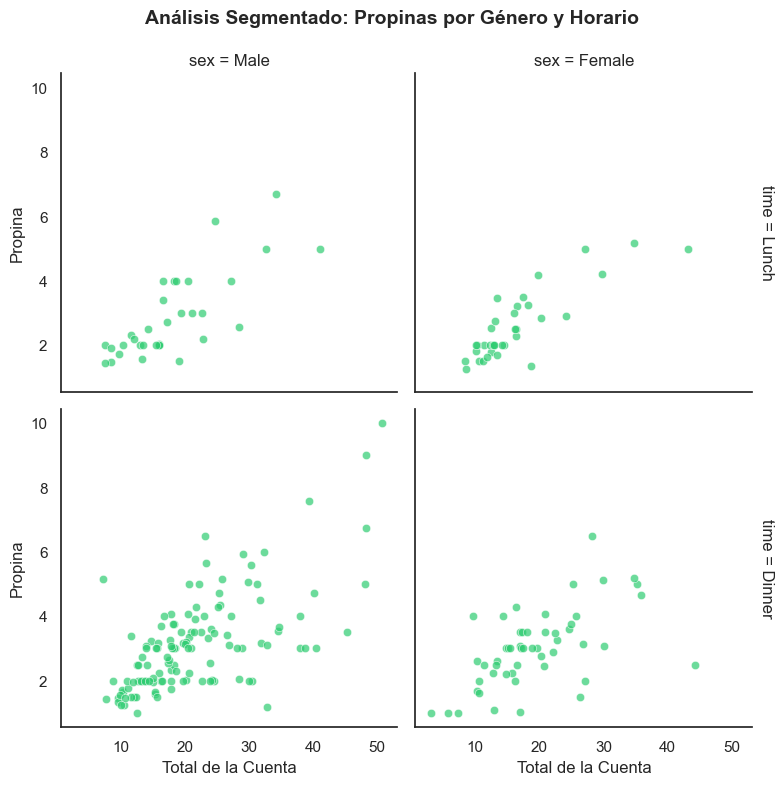

In [6]:
def analisis_seaborn_pro(df):
    """
    Genera visualizaciones estadísticas avanzadas: 
    1. Un Mapa de Calor de correlación lineal.
    2. Un FacetGrid para segmentación multidimensional.
    """
    sns.set_theme(style="white") # Tema minimalista
    
    # --- 1. MAPA DE CALOR (Heatmap) ---
    plt.figure(figsize=(7, 5))
    # Seleccionamos solo las columnas numéricas para la matriz de correlación
    df_numerico = df.select_dtypes(include=['float64', 'int64'])
    matriz_correlacion = df_numerico.corr()
    
    # annot=True imprime el número dentro del cuadro, cmap define la escala de colores
    sns.heatmap(matriz_correlacion, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
    plt.title("Matriz de Correlación: Variables Numéricas", fontweight='bold')
    plt.show()
    
    # --- 2. FACET GRID COMPUESTO ---
    print("\n")
    # Creamos una cuadrícula segmentando filas por 'time' (Comida/Cena) y columnas por 'sex' (Género)
    grid = sns.FacetGrid(df, col="sex", row="time", margin_titles=True, height=4)
    
    # "Mapeamos" un gráfico de dispersión (scatter) dentro de cada cuadrícula
    grid.map_dataframe(sns.scatterplot, x="total_bill", y="tip", alpha=0.7, color="#2ecc71")
    grid.set_axis_labels("Total de la Cuenta", "Propina")
    grid.figure.subplots_adjust(top=0.9) # Espacio para el título global
    grid.figure.suptitle("Análisis Segmentado: Propinas por Género y Horario", fontweight='bold', fontsize=14)
    plt.show()

# --- Ejecución Pro ---
if __name__ == "__main__":
    analisis_seaborn_pro(df_tips)

## 🔍 Explicación de la Versión Profesional

1. **Mapa de Calor (`heatmap`)**: Calculamos la matriz matemática de correlación de Pearson con `.corr()`. El heatmap traduce esos números (entre -1 y 1) en colores. Si el cuadro es muy rojo, significa que cuando una variable sube, la otra también (ej. cuenta total y propina). Es la herramienta favorita de los Científicos de Datos para encontrar patrones rápidos.
2. **`FacetGrid`**: En lugar de hacer 4 gráficos separados manualmente, le dijimos a Seaborn: "Crea una matriz usando las filas del Horario (Lunch/Dinner) y las columnas del Género (Male/Female)". Luego aplicamos (`.map_dataframe`) un gráfico de dispersión a cada cuadrito. Esta es la forma más limpia de visualizar 4 dimensiones a la vez sin saturar la vista.

# 🎉 Conclusión del Cuaderno: Visualización Estadística Avanzada

¡Excelente trabajo finalizando este tema!

Si Matplotlib nos enseñó a construir la estructura y los cimientos de un gráfico, **Seaborn** nos enseñó a decorarlo y a llevarlo a un nivel de diseño profesional. En este último cuaderno, elevamos drásticamente la calidad visual e interpretativa de nuestros datos escribiendo apenas una fracción del código.

### 🧠 ¿Qué nos llevamos de este cuaderno?
* **Estética Profesional:** Aprendimos a usar herramientas como `set_style` y paletas de colores para dejar atrás los gráficos por defecto y generar reportes listos para presentaciones directivas.
* **Distribuciones Complejas:** Exploramos cómo las funciones KDE y los `violinplots` revelan la anatomía interna de los datos, mostrando dónde se concentra la verdadera densidad poblacional más allá de un simple promedio estadístico.
* **Análisis Multidimensional:** Descubrimos que al aprovechar parámetros automáticos como `hue`, y al utilizar `lmplot` o `FacetGrid`, podemos cruzar 3 o 4 variables diferentes en una sola imagen sin abrumar al espectador.
* **Mapas de Correlación:** Integramos el análisis matemático con la representación visual a través de los Mapas de Calor (`heatmap`), un paso absolutamente obligatorio para identificar qué variables importan más antes de crear cualquier modelo predictivo.

---
**🏆 Preparación para el mundo real:** Con este dominio sobre las visualizaciones de Seaborn, tu capacidad para contar historias con los datos (*Data Storytelling*) está en un nivel altamente competitivo. Tienes todo el ecosistema analítico necesario para desarrollar proyectos de portafolio completos y enfrentarte a cualquier conjunto de datos.

## 📚 Glosario de Visualización con Seaborn



Para dominar completamente las herramientas de visualización de Python, aquí tienes la terminología clave del ecosistema de Seaborn:

* **Facet Grid:** Una herramienta de Seaborn que permite crear gráficos compuestos segmentando los datos por categorías (creando una matriz de "sub-gráficos"), facilitando la visualización limpia de múltiples aspectos en una sola figura.
* **Factorplot (ahora `catplot`):** Una función de Seaborn que genera gráficos categóricos, permitiendo la comparación rápida de diferentes grupos dentro de un conjunto de datos en una misma grilla.
* **Funciones de densidad kernel (KDE):** Una técnica estadística utilizada para estimar la densidad de probabilidad de una variable continua de manera suave y continua. A menudo se superpone en histogramas para mejorar la interpretación visual.
* **Jointplot:** Una función que combina gráficos de dispersión (centro) y densidad/histogramas (márgenes), mostrando relaciones bivariadas y distribuciones univariadas simultáneamente.
* **lmplot:** Una función que permite crear diagramas de dispersión integrando automáticamente líneas de regresión lineal, facilitando el modelado visual de tendencias (incluso segmentadas por colores).
* **Mapas de calor (Heatmaps):** Gráficos que utilizan una escala de colores para representar valores numéricos en una matriz. Son universalmente utilizados en Data Science para visualizar matrices de correlación entre variables.
* **Regplot:** Función base de Seaborn que crea diagramas de dispersión individuales con una línea de regresión estadística superpuesta.
* **Seaborn:** Biblioteca de visualización de datos en Python construida sobre Matplotlib. Proporciona una interfaz de alto nivel para dibujar gráficos estadísticos atractivos, complejos e informativos con muy pocas líneas de código.
* **Styles de visualización:** Opciones nativas en Seaborn (como `sns.set_style("darkgrid")`) para cambiar la estética global de los gráficos de forma instantánea, afectando el fondo, los colores y las líneas de la cuadrícula.
* **Violinplot:** Un tipo de gráfico avanzado que combina características de los diagramas de caja (cuartiles) y KDE. Muestra la distribución estadística completa de los datos a través del grosor de su silueta.

# 🎉🏆 GRAN CONCLUSIÓN DEL MÓDULO 1: FUNDAMENTOS DE DATA SCIENCE

¡Muchísimas felicidades! Has llegado al final del Módulo 1. 

A lo largo de estos cuadernos, has construido una base técnica increíblemente sólida y profesional. Empezamos desde lo más microscópico (variables y listas), hasta llegar a la arquitectura de software (Programación Orientada a Objetos) y culminar con el ecosistema analítico (Pandas, NumPy, Matplotlib y Seaborn).

### 🧠 Tu Nuevo Arsenal de Herramientas:
1. **Lógica Algorítmica:** Estructuras de control, ciclos `for`/`while` y manejo de excepciones.
2. **Ingeniería de Software:** Modularidad con Funciones, Clases, Objetos y Buenas Prácticas (Clean Code).
3. **Manejo de Datos Masivos:** Filtrado, agregación y operaciones matemáticas vectorizadas hiperrápidas.
4. **Data Storytelling:** Capacidad para traducir tablas aburridas en gráficos interactivos, mapas de calor y dashboards estadísticos.

**¡El mundo de los datos es tuyo! Mucho éxito en tu proyecto.** 🚀📊